In [1]:
# header for current kernel
from pyCHX.chx_packages import *
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import matplotlib.patches as mpatches
from copy import deepcopy
from scipy.signal import argrelmax

%run /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/standard_functions.py
%run /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/chx_analysis_setup.ipynb
%run -i /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/archiver_setup.py

Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard
setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/
ran "%run -i /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/roi_nr_2019_3_0_1.py" to fix ROI numbering for PHI-sliced data sets. Should get fixed in pyCHX...
ran "%run -i /nsls2/data/chx/legacy/analysis/2023_2/lwiegart/pyCHX_June2023/chx_outlier_detection.py": this should become part of pyCHX.
ran "%run -i /nsls2/data/chx/legacy/analysis/2023_2/lwiegart/pyCHX_June2023/fix_get_sid_filenames.py": this should be fixed and re-deployed in pyCHX.

environment dependent settings and patches:
using "%matplotlib inline" for plotting
ran "%run -i /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/polygonmask_fix.py".
ran "%run -i /nsls2/data/chx/legacy/analysis/2023_2/lwiegart/pyCHX_June2023/chx_compress.py": temporary fix for depreciated np.float.
ran "%run -i /nsls2/data/chx/legacy/analysis/2023

In [2]:
pip install scikit-guess

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: py4xs 2023.1.23.0 has a non-standard dependency specifier scipy>-=1.6. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of py4xs or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Note: you may need to restart the kernel to use updated packages.


In [3]:
import skg # this wouldn't work running jupyter hub on CHX srv2 environment

### Specify dataset to load

In [100]:
user = 'cai'
cycle = '2024_3'

# silver behenate colibration (list should contain only one scan_id or uid)
scan_list =  [157601] # WAXS detector position optimized for Rufina's samples
scan_list =  [157615] # WAXS detector position optimized PP 3D printing
scan_list =  [159929] # WAXS detector ~130mm

result_dir = '%s%s/%s/%s/'%(_base_path_,cycle,user,'Results')

###############################################################################################################
(scan_list,uid)=get_uid_list(scan_list,user=user,cycle=cycle,uid_length=8,verbose=True)
assert len(uid)==1,'list should only contain one scan_id or uid'
filepath=result_dir+'Pilatus_800k_calibration_uid_%s.pkl'%uid[0]
print('IF output will be saved, it will be saved as: %s'%filepath)

uid list: 75a5f055  ->  scan list: 159929
IF output will be saved, it will be saved as: /nsls2/data/chx/legacy/analysis/2024_3/cai/Results/Pilatus_800k_calibration_uid_75a5f055.pkl


### Calibration setup

In [103]:
center=(701,374) # guess for beam center [detector pixles]
#box_width=198 # width of box (around guessed beam center) to contain at least the first diffraction ring of the calibrant
box_width=124

calibrant_name = 'AgBh' # name of calibrant (needs to match pyFai library, only tested for 'AgBh')

### below should be metadata information
md=get_meta_data(uid[0])
sample_det_distance = md['pilatus800k sample-detector distance']/1000  # this is NOT a detector PV...name could change depending on user
# currently don't have detector metadata for energy...
pv_E = 'XF:11IDA-OP{Mono:DCM-Ax:Energy}Mtr.RBV'
res_dict=get_archived_pvs_from_uid(pv_list=[pv_E],uid=uid[0],pre=10,post=0,verbose=True)
E=np.average(res_dict[pv_E]['data'])
wavelength=1E-9*(1239.8/E)

print('sample detector distance: %s[m]    X-ray wavelength: %s[m]'%(np.round(sample_det_distance,3),wavelength))

couldn't find image shape...skip!
getting archived data for PVs ['XF:11IDA-OP{Mono:DCM-Ax:Energy}Mtr.RBV']
uid: 75a5f055
time: start of uid - 10s to end of uid +0s
2024-10-31 13:51:19 - 2024-10-31 13:51:30
sample detector distance: 0.13[m]    X-ray wavelength: 8.853817039205885e-11[m]


### plot data with approximate beam center

pilatus800_image


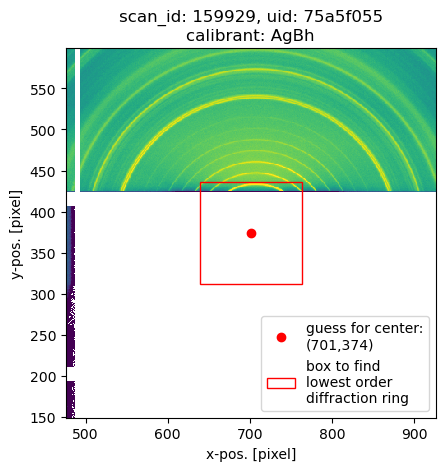

In [104]:
h=db[uid[0]]
f=h.start['detectors'][0]+'_image'
print(f)
im=list(h.data(f))

img = np.flipud(im[0][0])
plt.imshow(img,norm='log',vmin=100,vmax=3000)
plt.title('scan_id: %s, uid: %s\ncalibrant: %s'%(scan_list[0],uid[0],calibrant_name))
plt.xlabel('x-pos. [pixel]');plt.ylabel('y-pos. [pixel]')
extend=450
plt.plot(center[0],center[1],'ro',label='guess for center:\n(%s,%s)'%(center[0],center[1]))
#c = mpatches.Circle(center,200,color='r',fill=False)

c= mpatches.Rectangle((center[0]-box_width/2,center[1]-box_width/2),box_width,box_width,color='r',fill=False,label='box to find \nlowest order \ndiffraction ring')

ax=plt.gca()
ax.add_patch(c)

plt.xlim(center[0]-extend/2,center[0]+extend/2);plt.ylim(center[1]-extend/2,center[1]+extend/2)
plt.legend(loc='lower right')

ax.set_aspect('equal')

### finding the beam center: 1$^{st}$ iteration

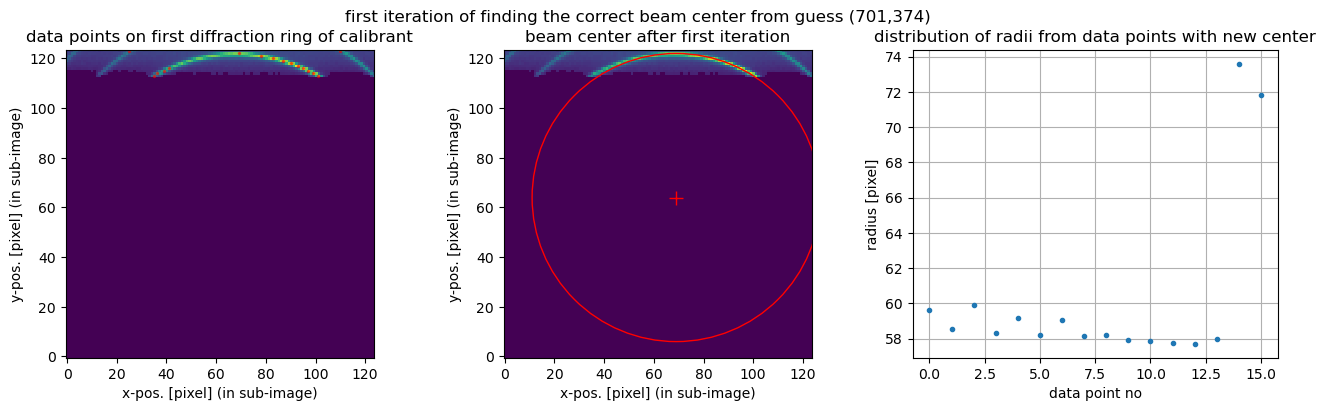

In [114]:
fitbox = img[int(center[1]-box_width/2):int(center[1]+box_width/2),int(center[0]-box_width/2):int(center[0]+box_width/2)]
# do some thresholding
ind2=fitbox< 5*np.nanmean(fitbox) # this is hardcoded, but maybe ok as long as silver behenate is used for calibration (intensity ratio of rings should be setup independent)

fitbox_=deepcopy(fitbox)
fitbox_[ind2]=0
#get local maxima

ind=argrelmax(fitbox_,axis=1,order=50)
fig,ax = plt.subplots(1,3,figsize=(16,4))
plt.suptitle('first iteration of finding the correct beam center from guess (%s,%s)'%(center[0],center[1]))
plt.subplot(1,3,1)
plt.imshow(fitbox_);plt.title('data points on first diffraction ring of calibrant')
plt.xlabel('x-pos. [pixel] (in sub-image)');plt.ylabel('y-pos. [pixel] (in sub-image)')
#plt.plot(center[0],center[1],'ro')
for i in range(len(ind[0])):
    plt.plot(ind[1][i],ind[0][i],'r.',markersize=3,alpha=.5)

# create dataset and fit to sphere:
data=[]
for i in range(len(ind[0])):
    data.append((ind[1][i],ind[0][i]))

r, c = skg.nsphere_fit(data,scaling=True)

cfit1 = mpatches.Circle(c,r,color='r',fill=False)


plt.subplot(1,3,2)
plt.imshow(fitbox_);plt.title('beam center after first iteration')
ax=plt.gca()
cp=deepcopy(cfit1)
ax.add_patch(cp)
ax.set_aspect('equal');xl=ax.get_xlim();yl=ax.get_ylim()
ax.plot(c[0],c[1],'r+',markersize=10)
ax.set_xlim(xl); ax.set_ylim(yl)
plt.xlabel('x-pos. [pixel] (in sub-image)');plt.ylabel('y-pos. [pixel] (in sub-image)')

radius = []
for d in data:
    radius.append(((d[0]-c[0])**2+(d[1]-c[1])**2)**.5)
plt.subplot(1,3,3);plt.title('distribution of radii from data points with new center')
plt.plot(radius,'.');plt.xlabel('data point no');plt.ylabel('radius [pixel]');plt.grid(True)

### finding the beam center: 2$^{nd}$ iteration

array([ 70.39976829, 141.89059059])

In [79]:
c=np.array([70,60])

beam_center x=707, y=369
beam_center x=707, y=369


Text(0, 0.5, 'y-pos [pixel]')

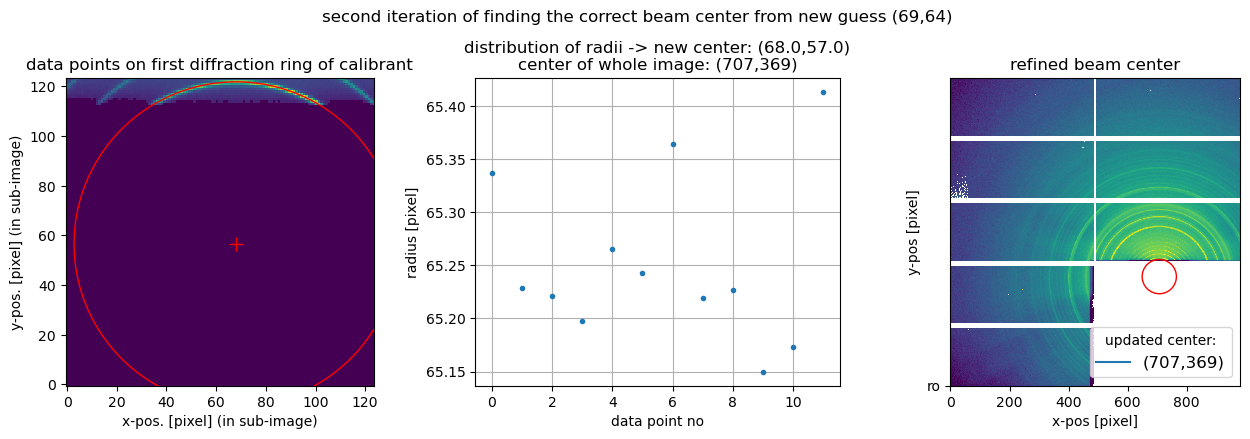

In [115]:
fig,ax = plt.subplots(1,3,figsize=(16,4))
plt.suptitle('second iteration of finding the correct beam center from new guess (%s,%s)'%(np.round(c[0]),np.round(c[1])),y=1.05)

out_ind=np.invert(is_outlier(np.array(radius),2.))
data_=np.array(data)[out_ind]

# fit again remaining data to circle:
r_, c_ = skg.nsphere_fit(data_,scaling=True)
cfit2 = mpatches.Circle(c_,r_,color='r',fill=False)


plt.subplot(1,3,1)
plt.imshow(fitbox_);plt.title('data points on first diffraction ring of calibrant')
ax=plt.gca()
cp=deepcopy(cfit2)
ax.add_patch(cp)
ax.set_aspect('equal');xl=ax.get_xlim();yl=ax.get_ylim()
ax.plot(c_[0],c_[1],'r+',markersize=10)
ax.set_xlim(xl); ax.set_ylim(yl)
plt.xlabel('x-pos. [pixel] (in sub-image)');plt.ylabel('y-pos. [pixel] (in sub-image)')

plt.subplot(1,3,2)
radius_ = []
for d in data_:
    radius_.append(((d[0]-c_[0])**2+(d[1]-c_[1])**2)**.5)
plt.plot(radius_,'.');plt.xlabel('data point no');plt.ylabel('radius [pixel]');plt.grid(True)
# need to calculat coordiantes back for whole image
beam_center=(int(np.round(center[0]+c_[0]-np.shape(fitbox)[0]/2,0)),int(np.round(center[1]+c_[1]-np.shape(fitbox)[1]/2,0)))
print('beam_center x=%s, y=%s'%(beam_center[0],beam_center[1]))
plt.title('distribution of radii -> new center: (%s,%s)\ncenter of whole image: (%s,%s)'%(np.round(c_[0]),np.round(c_[1]),beam_center[0],beam_center[1]))

plt.subplot(1,3,3)
# need to calculate coordiantes back for whole image
beam_center=(int(np.round(center[0]+c_[0]-np.shape(fitbox)[0]/2,0)),int(np.round(center[1]+c_[1]-np.shape(fitbox)[1]/2,0)))
print('beam_center x=%s, y=%s'%(beam_center[0],beam_center[1]))

### plot whole image with fitted center and radius of 0-order peak

plt.imshow(img,norm='log',vmin=100,vmax=3000);plt.title('refined beam center')

plt.plot('ro',label='(%s,%s)'%(beam_center[0],beam_center[1]))
plt.legend(title='updated center:',loc='lower right',fontsize=12)
circ = mpatches.Circle(beam_center,r,color='r',fill=False)
circ1=deepcopy(circ)
ax=plt.gca()
ax.add_patch(circ1)
ax.set_aspect('equal')
plt.xlabel('x-pos [pixel]');plt.ylabel('y-pos [pixel]')


### Further Geometry Refinement with pyFAI

In [116]:
import pyFAI
from pyFAI import calibrant
from pyFAI import geometryRefinement

### create masks

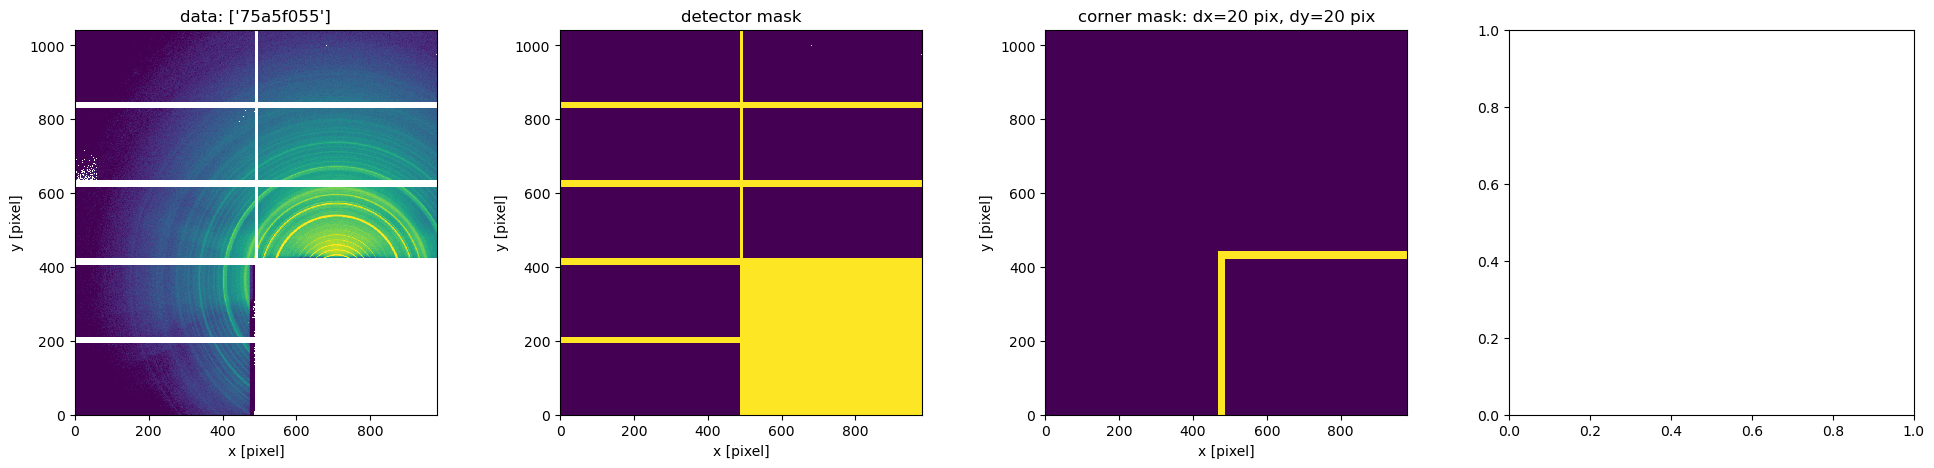

In [117]:
corner_masking = True # mask stripe of pixels with widht dx,dy around detector cutout
dx=20
dy=20

platform_masking = False
px=500
py=250

fix,ax = plt.subplots(1,4,figsize=(24,5))
plt.subplot(1,4,1)
plt.imshow(img,norm='log',vmin=200,vmax=2000)
plt.title('data: %s'%uid);plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

mask = np.zeros(np.shape(img))
m = img<0
mask[m]=1
plt.subplot(1,4,2)
plt.imshow(mask)
plt.title('detector mask');plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

plt.subplot(1,4,3)
corner_mask=np.zeros(shape(mask))
if corner_masking:
    corner_mask[0:423+dx,487-dx:487]=1
    corner_mask[423:423+dy,487-dx:]=1
    plt.imshow(corner_mask);plt.title('corner mask: dx=%s pix, dy=%s pix'%(dx,dy));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

plt.subplot(1,4,4)
platform_mask=np.zeros(shape(mask))
if platform_masking:
    platform_mask[0:py+dx,0:px]=1
    plt.imshow(platform_mask);plt.title('platform mask: px=%s pix, py=%s pix'%(px,py));plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
mask_=mask+corner_mask+platform_mask

### setting up detector and geometry for calibration of detector geometry

In [118]:
detector = pyFAI.detector_factory("Pilatus1M")
aintegrator=pyFAI.azimuthalIntegrator.AzimuthalIntegrator(dist=sample_det_distance, poni1=beam_center[1]*detector.pixel1, poni2=beam_center[0]*detector.pixel2, rot1=0, rot2=0, rot3=0, pixel1=None, pixel2=None, splineFile=None, detector=detector, wavelength=wavelength)
calibrant = pyFAI.calibrant.get_calibrant(calibrant_name,wavelength=wavelength)
pyFAI.calibrant.Calibrant.save_dSpacing(calibrant,filename=calibrant_name) # this is required to use 'calibrant' in geometry refinement...

### measured and theoretical peak position without geometry refinement

Text(0, 0.5, 'integrated intensity [arb.u.]')

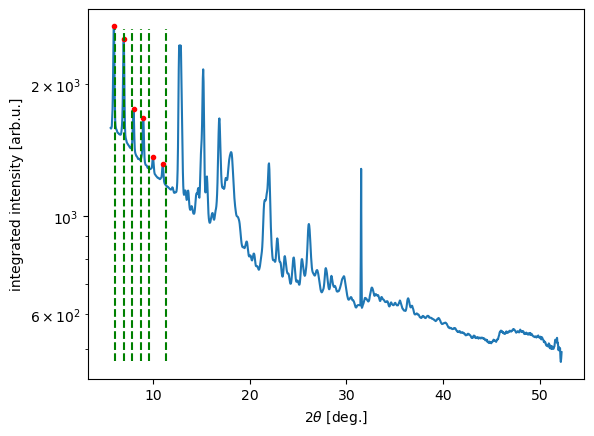

In [119]:
azi_2th = aintegrator.integrate1d(img,npt=1200,mask=mask_,unit='2th_deg')
plt.semilogy(azi_2th[0],azi_2th[1])
# find local maxima:
from scipy.signal import argrelextrema
max_2th = 12 #max range to look for extrema
ind = azi_2th[0]<=max_2th
amax = argrelextrema(azi_2th[1][ind], np.greater,order=20)

for a in amax[0]:
    plt.semilogy(azi_2th[0][a],azi_2th[1][a],'r.')

    
delta=1.5
rings_2th = azi_2th[0][amax]
peak_list=calibrant.get_peaks(unit='2th_deg')
index=[];peak_2th=[]
for a in rings_2th:
    m=np.argmin(np.abs(peak_list-a))
    if np.abs(peak_list[m]-a) <= delta:
        index.append(m);peak_2th.append(peak_list[m])
ax=plt.gca()
yl=ax.get_ylim()
index=sorted(list(set(index)))
for ii,i in enumerate(index):
    plt.semilogy([peak_2th[ii],peak_2th[ii]],[yl[0]*1.1,yl[1]*.9],'g--')
    
plt.xlabel(r'2$\theta$ [deg.]');plt.ylabel('integrated intensity [arb.u.]')

### 1$^{st}$ refinement: optimize sample-detector distance only using some low order rings

In [120]:
search_ind_order = 5 # initial search for peak positions up to index of order search_ind_order (starts at 0!)
d_pix= 20 # maximum difference between measured and theoretical peak position
histogram_thresh = .1 # threshold for histogram: only bins with a count >  histogram_thresh * total number of datapoints will be considered 'valid' radii


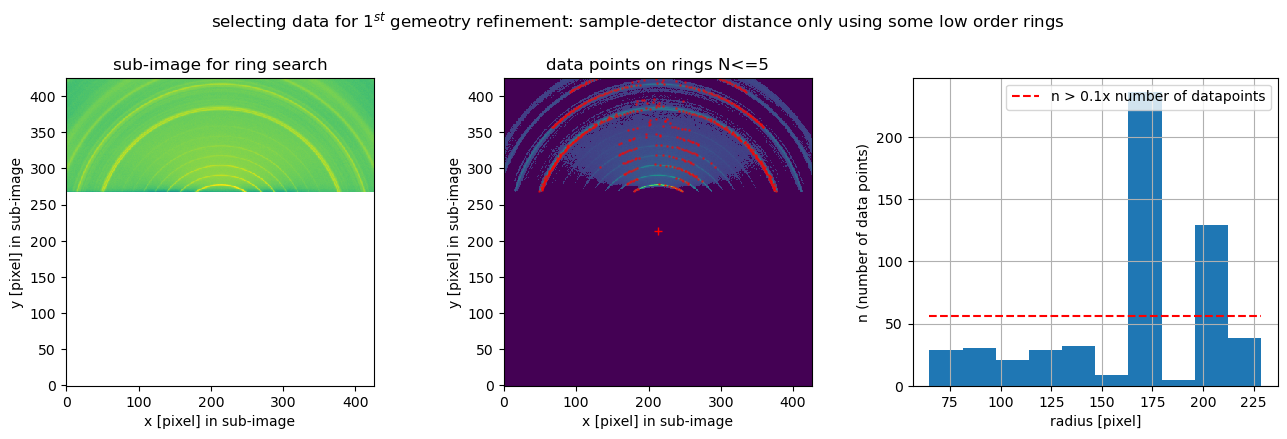

In [127]:
cali_map=calibrant.fake_calibration_image(aintegrator,W=1E-5)
radial_strip = cali_map[beam_center[1],beam_center[0]:]
h=radial_strip<1E-3 # there are some (numerical?) fluctuations that get picked up as relative maxima...
radial_strip[h]=0
ring_rad_pix = argrelmax(radial_strip,order=20)[0]
box_width=d_pix+ring_rad_pix[search_ind_order]
fitbox = img[int(beam_center[1]-box_width):int(beam_center[1]+box_width),int(beam_center[0]-box_width):int(beam_center[0]+box_width)]

fig,ax = plt.subplots(1,3,figsize=(16,4))
plt.suptitle('selecting data for 1$^{st}$ gemeotry refinement: sample-detector distance only using some low order rings',y=1.05)

plt.subplot(1,3,1);plt.title('sub-image for ring search')
plt.imshow(fitbox,norm='log');plt.xlabel('x [pixel] in sub-image');plt.ylabel('y [pixel] in sub-image')

plt.subplot(1,3,2);plt.title('data points on rings N<=%s'%search_ind_order)
ind2=fitbox< 2.5*np.nanmean(fitbox) # this is hardcoded, but maybe ok as long as silver behenate is used for calibration (intensity ratio of rings should be setup independent)

fitbox_=deepcopy(fitbox)
fitbox_[ind2]=0
#get local maxima

ind=argrelmax(fitbox_,axis=1,order=50)
plt.imshow(fitbox_)
radius=[]
plt.plot(box_width,box_width,'r+')
for i in range(len(ind[0])):
    plt.plot(ind[1][i],ind[0][i],'r.',markersize=2,alpha=.5)
    radius.append(((ind[1][i]-box_width)**2+(ind[0][i]-box_width)**2)**.5)
plt.xlabel('x [pixel] in sub-image');plt.ylabel('y [pixel] in sub-image')

radius_hist = np.histogram(radius)
plt.subplot(1,3,3)
plt.hist(radius,radius_hist[1]);plt.xlabel('radius [pixel]');plt.ylabel('n (number of data points)');plt.grid(True)
plt.plot([radius_hist[1][0],radius_hist[1][-1]],len(radius)*np.array([histogram_thresh,histogram_thresh]),'r--',label='n > %sx number of datapoints'%histogram_thresh)
plt.legend(loc='upper right')


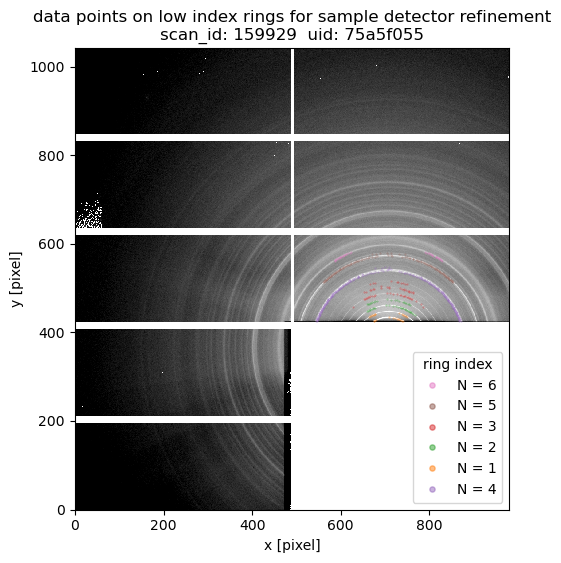

In [134]:
# downselect histogram: ignore bins with less than 10% of total number of found maxima to create 'valid radii' list
radii_list=[];sum_i=0
for ii,i in enumerate(radius_hist[0]):
    if i>=.1*len(radius):
        radii_list.append(radius_hist[1][ii:ii+2])
        sum_i+=i
ave_radii_list = np.average(radii_list,axis=1)
rad_index=[]
for r in ave_radii_list:
    rad_index.append([r,np.argmin(np.abs(ring_rad_pix-r))])
rad_index=[]
for r in ave_radii_list:
    rad_index.append([r,np.argmin(np.abs(ring_rad_pix-r))])
    
# create data for geometry refinement module
data=np.ndarray(shape=(sum_i,3))
pixel_position_x=[];pixel_position_y=[];pixel_index=[]
for i in range(len(ind[0])):
   # plt.plot(ind[1][i],ind[0][i],'r.')
    r=((ind[1][i]-box_width)**2+(ind[0][i]-box_width)**2)**.5
    for ll,l in enumerate(radii_list):
        if r >= l[0] and r <= l[1]:
            pixel_position_x.append(ind[1][i]+beam_center[0]-box_width)
            pixel_position_y.append(ind[0][i]+beam_center[1]-box_width)
            pixel_index.append(int(rad_index[ll][1]))
            #ring_info.append([ind[1][i]+beam_center[0]-box_width,ind[0][i]+beam_center[1]-box_width,rad_index[ll][1]])
data[:,0]=pixel_position_y
data[:,1]=pixel_position_x
data[:,2]=pixel_index

## add legend with index, label with calibrant
fig,ax=plt.subplots(figsize=(6,6))
plt.imshow(img,norm='log',vmin=200,vmax=3000,cmap='gray');plt.title('data points on low index rings for sample detector refinement\nscan_id: %s  uid: %s'%(scan_list[0],uid[0]))
plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')
color_list=[]
for i in range(np.shape(data)[0]):
    if data[i][2] not in color_list:
        color_list.append(data[i][2])
        lab='N = %s'%int(data[i][2])
    else:
        lab=''
    plt.plot(data[i][1],data[i][0],'.',color='C%s'%int(data[i][2]),markersize=.75,alpha=.5,label=lab)
plt.legend(title='ring index',loc='lower right',scatterpoints=3,markerscale=10,reverse=True)

### refine sample-detector distance only

In [136]:
geo_refine=pyFAI.geometryRefinement.GeometryRefinement(data=data, dist=sample_det_distance, poni1=beam_center[1]*detector.pixel1, poni2=beam_center[0]*detector.pixel2, rot1=0, rot2=0, rot3=0, detector=detector, wavelength=wavelength, calibrant=calibrant)
print('initial geometry parameters:')
print(geo_refine)
residuals = geo_refine.refine3(fix=['poni1','poni2','rot1','rot2','rot3','wavelength','center'])
print('\nresiduals for initial refinement: %s\nupdated geometry parameters:'%residuals)
print(geo_refine)

sample_det_distance = geo_refine.get_dist()
# update aintegrator with new sample-detector distance !!!
aintegrator=pyFAI.azimuthalIntegrator.AzimuthalIntegrator(dist=sample_det_distance, poni1=beam_center[1]*detector.pixel1, poni2=beam_center[0]*detector.pixel2, rot1=0, rot2=0, rot3=0, pixel1=None, pixel2=None, splineFile=None, detector=detector, wavelength=wavelength)

initial geometry parameters:
Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 8.853817e-11 m
SampleDetDist= 1.400000e-01 m	PONI= 6.346800e-02, 1.216040e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 140.000 mm	Center: x=707.000, y=369.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 0.885Å

residuals for initial refinement: 6.84597815905763e-06
updated geometry parameters:
Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 8.853817e-11 m
SampleDetDist= 3.832882e-01 m	PONI= 6.346800e-02, 1.216040e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 383.288 mm	Center: x=707.000, y=369.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 0.885Å


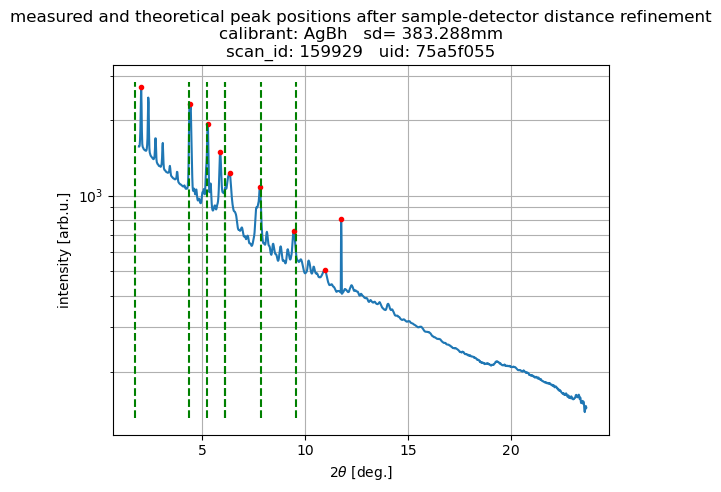

In [137]:
azi_2th = aintegrator.integrate1d(img,npt=1200,mask=mask_,unit='2th_deg')
plt.semilogy(azi_2th[0],azi_2th[1])
plt.title('measured and theoretical peak positions after sample-detector distance refinement\ncalibrant: %s   sd= %smm\nscan_id: %s   uid: %s'%(calibrant_name,np.round(sample_det_distance*1000,3),scan_list[0],uid[0]))
# find local maxima:
from scipy.signal import argrelextrema
max_2th = 12 #max range to look for extrema
ind = azi_2th[0]<=max_2th
amax = argrelextrema(azi_2th[1][ind], np.greater,order=20)

for a in amax[0]:
    plt.semilogy(azi_2th[0][a],azi_2th[1][a],'r.')

    
delta=1.5
rings_2th = azi_2th[0][amax]
peak_list=calibrant.get_peaks(unit='2th_deg')
index=[];peak_2th=[]
for a in rings_2th:
    m=np.argmin(np.abs(peak_list-a))
    if np.abs(peak_list[m]-a) <= delta:
        index.append(m);peak_2th.append(peak_list[m])
ax=plt.gca()
yl=ax.get_ylim()
index=sorted(list(set(index)))
for ii,i in enumerate(index):
    plt.semilogy([peak_2th[ii],peak_2th[ii]],[yl[0]*1.1,yl[1]*.9],'g--')
plt.xlabel(r'2$\theta$ [deg.]');plt.ylabel('intensity [arb.u.]');plt.grid(True,which='both')


## Full Geometry Refinement

### setup

In [138]:
ddr=5  # maximum allowed difference between theoretical and measured peak positions [pixel]
dr=10 # radii within this value will be assumed to be the same radius

In [139]:
### get all possible radii from fake calibration image: take cuts along the 4 principle directions
cali_map=calibrant.fake_calibration_image(aintegrator,W=1E-6)
ring_rad_pix_ = []
for i in range(4):
    if i == 0:
        radial_strip = cali_map[beam_center[1],beam_center[0]:]
    elif i == 1:
        radial_strip = cali_map[beam_center[1]:,beam_center[0]]
    elif i == 2:
        radial_strip = cali_map[:beam_center[1],beam_center[0]]
        radial_strip = np.flip(radial_strip)
    elif i == 3:
        radial_strip = cali_map[beam_center[1],:beam_center[0]]
        radial_strip = np.flip(radial_strip)
    h=radial_strip<1E-3;radial_strip[h]=0
    ring_rad_pix_+=(argrelmax(radial_strip, order=20)[0].tolist())
ring_rad_pix_=sorted(list(set(ring_rad_pix_)))
# # ensure we're not double counting some close values...not sure if the same threshold would work for any calibrant, but probably ok for AgBh
dx=[]
for i in range(len(ring_rad_pix_)):
    if i == 0:
        dx.append(ring_rad_pix_[i]-0)
    else:
        dx.append(ring_rad_pix_[i]-ring_rad_pix_[i-1])
dx=np.array(dx)
h=dx>dr
ring_rad_pix=np.array(ring_rad_pix_)[h]

# # ensure we're not double counting some close values...not sure if the same threshold would work for any calibrant, but probably ok for AgBh
dx=[]
for i in range(len(ring_rad_pix_)):
    if i == 0:
        dx.append(ring_rad_pix_[i]-0)
    else:
        dx.append(ring_rad_pix_[i]-ring_rad_pix_[i-1])
dx=np.array(dx)
h=dx>dr;dx=dx[h]
ring_rad_pix=np.array(ring_rad_pix_)[h]

/tmp/ipykernel_15678/190477075.py:10: RuntimeWarning: Mean of empty slice
  g=tmp<2*np.nanmean(tmp)


geometry parameters before final refinement:
Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 8.853817e-11 m
SampleDetDist= 3.832882e-01 m	PONI= 6.346800e-02, 1.216040e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 383.288 mm	Center: x=707.000, y=369.000 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 0.885Å

residuals for final refinement: 6.539923412382132e-06
updated geometry parameters:
Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 8.853817e-11 m
SampleDetDist= 3.909312e-01 m	PONI= 6.270496e-02, 1.216434e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 390.931 mm	Center: x=707.229, y=364.564 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 0.885Å


Text(0, 0.5, 'y [pixel]')

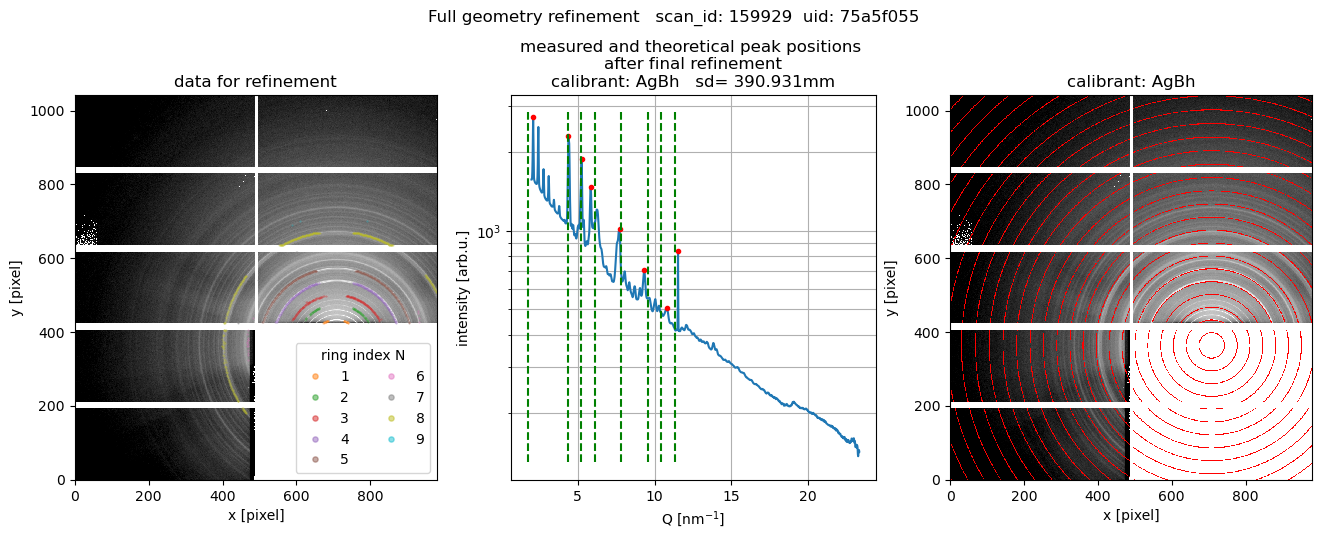

In [140]:
x_pos=[];y_pos=[];index_=[]
for i in range(len(ring_rad_pix)):
    ma=np.zeros(np.shape(img))*np.nan;mi=np.ones(np.shape(img))
    if i == 0:
        ma[beam_center[1]-ring_rad_pix[i]-ddr:beam_center[1]+ring_rad_pix[i]+ddr,beam_center[0]-ring_rad_pix[i]-ddr:beam_center[0]+ring_rad_pix[i]+ddr]=1
    else:
        mi[beam_center[1]-ring_rad_pix[i-2]-ddr:beam_center[1]+ring_rad_pix[i-2]+ddr,beam_center[0]-ring_rad_pix[i-2]-ddr:beam_center[0]+ring_rad_pix[i-2]+ddr]=np.nan
        ma[beam_center[1]-ring_rad_pix[i]-ddr:beam_center[1]+ring_rad_pix[i]+ddr,beam_center[0]-ring_rad_pix[i]-ddr:beam_center[0]+ring_rad_pix[i]+ddr]=1
    tmp=ma*mi*img
    g=tmp<2*np.nanmean(tmp)
    tmp[g]=0

    ind = argrelmax(tmp, order=dr)
    r=((ind[1]-beam_center[0])**2+(ind[0]-beam_center[1])**2)**.5
    id1=r<=ring_rad_pix[i]+ddr;id2=r>=ring_rad_pix[i]-ddr

    x_pos+=list(ind[0][id1*id2])
    y_pos+=list(ind[1][id1*id2])
    index_+=list(i*np.ones(len(ind[1][id1*id2])))

    
# create data for geometry refinement module
data2=np.ndarray(shape=(len(x_pos),3))
data2[:,0]=x_pos
data2[:,1]=y_pos
data2[:,2]=index_

fig,ax = plt.subplots(1,3,figsize=(16,5))
plt.suptitle('Full geometry refinement   scan_id: %s  uid: %s'%(scan_list[0],uid[0]),y=1.05)

plt.subplot(1,3,1);plt.title('data for refinement')
plt.imshow(img,norm='log',vmin=200,vmax=3000,cmap='gray')
color_list = []
for i in range(np.shape(data2)[0]):
    if data2[i][2] not in color_list:
        color_list.append(data2[i][2])
        lab='%s'%int(data2[i][2])
    else:
        lab=''
    plt.plot(data2[i][1],data2[i][0],'.',color='C%s'%int(data2[i][2]),markersize=.75,alpha=.5,label=lab)
plt.legend(title='ring index N',loc='lower right',scatterpoints=3,markerscale=10,reverse=False,ncols=2)
plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

geo_refine=pyFAI.geometryRefinement.GeometryRefinement(data=data, dist=sample_det_distance, poni1=beam_center[1]*detector.pixel1, poni2=beam_center[0]*detector.pixel2, rot1=0, rot2=0, rot3=0, detector=detector, wavelength=wavelength, calibrant=calibrant)
print('geometry parameters before final refinement:')
print(geo_refine)
residuals2=geo_refine.refine3(fix=['rot1','rot2','rot3','wavelength'])#['poni1','poni2','rot1','rot2','rot3','wavelength'])
print('\nresiduals for final refinement: %s\nupdated geometry parameters:'%residuals2)
print(geo_refine)
geo_config=geo_refine.get_config()
# update aintegrator with new sample-detector distance !!!
aintegrator=pyFAI.azimuthalIntegrator.AzimuthalIntegrator(dist=geo_config['dist'], poni1=geo_config['poni1'], poni2=geo_config['poni2'], rot1=geo_config['rot1'], rot2=geo_config['rot2'], rot3=geo_config['rot3'], pixel1=None, pixel2=None, splineFile=None, detector=detector, wavelength=wavelength)

plt.subplot(1,3,2)
azi_2th = aintegrator.integrate1d(img,npt=1200,mask=mask_,unit='2th_deg')
plt.semilogy(azi_2th[0],azi_2th[1])
plt.title('measured and theoretical peak positions \nafter final refinement\ncalibrant: %s   sd= %smm'%(calibrant_name,np.round(geo_config['dist']*1000,3)))
# find local maxima:
from scipy.signal import argrelextrema
max_2th = 12 #max range to look for extrema
ind = azi_2th[0]<=max_2th
amax = argrelextrema(azi_2th[1][ind], np.greater,order=20)

for a in amax[0]:
    plt.semilogy(azi_2th[0][a],azi_2th[1][a],'r.')

    
delta=1.5
rings_2th = azi_2th[0][amax]
peak_list=calibrant.get_peaks(unit='2th_deg')
index=[];peak_2th=[]
for a in rings_2th:
    m=np.argmin(np.abs(peak_list-a))
    if np.abs(peak_list[m]-a) <= delta:
        index.append(m);peak_2th.append(peak_list[m])
ax=plt.gca()
yl=ax.get_ylim()
index=sorted(list(set(index)))
for ii,i in enumerate(index):
    plt.semilogy([peak_2th[ii],peak_2th[ii]],[yl[0]*1.1,yl[1]*.9],'g--')
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('intensity [arb.u.]');plt.grid(True,which='both')

plt.subplot(1,3,3);plt.title('calibrant: %s'%calibrant_name)
cali_map = calibrant.fake_calibration_image(aintegrator,W=1E-6)
u=cali_map<.5;cali_map[u]=np.nan
u=cali_map>.5;cali_map[u]=1
plt.imshow(img,norm='log',vmin=200,vmax=3000,cmap='gray')
plt.imshow(cali_map,cmap='hsv')
plt.xlabel('x [pixel]');plt.ylabel('y [pixel]')

### Save Geometry Calibration (requires flag!)

In [47]:
print('IF True, calibration data would be saved as %s'%filepath)
if False:
    u=get_meta_data(uid[0],verbose=False)['uid']
    # there seems to be no good method to get the refined beam center back...?
    x_beam_pos = float(str(geo_refine).split('Center:')[-1].split('=')[1].split(',')[0])
    y_beam_pos = float(str(geo_refine).split('Center:')[-1].split('=')[2].split(',')[0].split(' ')[0])
    config_dict = {'scan_id':scan_list[0],'uid':u,'calibrant':calibrant_name,'detector':geo_config['detector'],'direct_beam_x':x_beam_pos,'direct_beam_y':y_beam_pos,
               'energy':geo_refine.get_energy(),'geo_config':geo_config}   
    save_pickle(filepath,config_dict,verbose=True)
   

IF True, calibration data would be saved as /nsls2/data/chx/legacy/analysis/2024_3/lwiegart/Results/Pilatus_800k_calibration_uid_f6ce48a5.pkl


In [22]:
_stop

NameError: name '_stop' is not defined

In [59]:
# how to load the calibration data and configure AzimuthalIntegrator
config_dict=load_pickle(filepath,verbose=True)
print(config_dict.keys())
aintegrator=pyFAI.azimuthalIntegrator.AzimuthalIntegrator(dist=config_dict['geo_config']['dist'], poni1=config_dict['geo_config']['poni1'], poni2=config_dict['geo_config']['poni2'],
                                                          rot1=config_dict['geo_config']['rot1'], rot2=config_dict['geo_config']['rot2'], rot3=config_dict['geo_config']['rot3'], 
                                                          pixel1=None, pixel2=None, splineFile=None, detector=config_dict['geo_config']['detector'], wavelength=config_dict['geo_config']['wavelength'])
aintegrator

Loading data from file: /nsls2/data/chx/legacy/analysis/2024_2/lwiegart/Results/Pilatus_800k_calibration_uid_e03f0866.pkl
dict_keys(['scan_id', 'uid', 'calibrant', 'detector', 'direct_beam_x', 'direct_beam_y', 'energy', 'geo_config'])


Detector Pilatus 1M	 PixelSize= 1.720e-04, 1.720e-04 m	 BottomRight (3)
Wavelength= 1.284634e-10 m
SampleDetDist= 3.185822e-01 m	PONI= 5.584996e-02, 1.072362e-01 m	rot1=0.000000  rot2=0.000000  rot3=0.000000 rad
DirectBeamDist= 318.582 mm	Center: x=623.466, y=324.709 pix	Tilt= 0.000° tiltPlanRotation= 0.000° 𝛌= 1.285Å

### try some radial integration

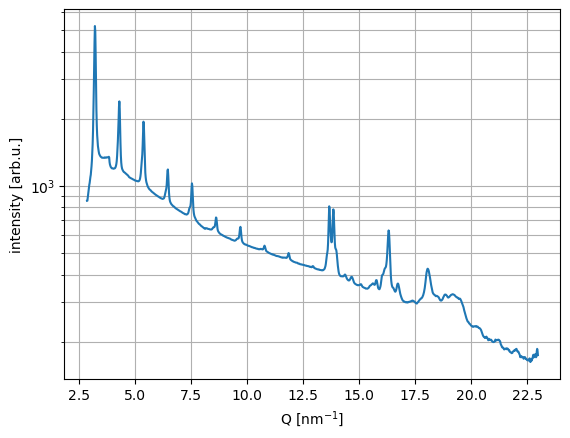

In [60]:
azi = aintegrator.integrate1d(img,npt=1200,mask=mask_)
plt.semilogy(azi[0],azi[1])
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('intensity [arb.u.]')
plt.grid(True,which='both')

Text(0, 0.5, '$\\Phi$ [$^o$]')

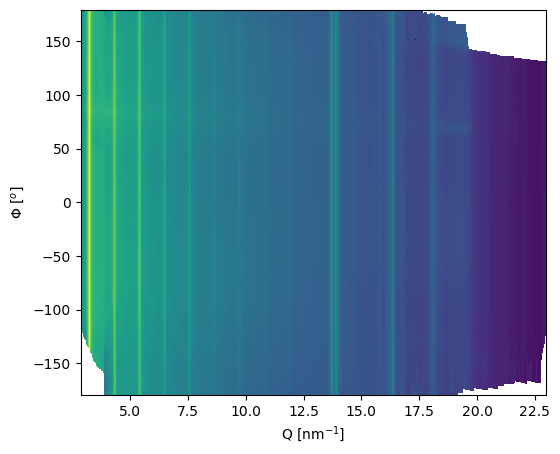

In [61]:
phi_map=aintegrator.integrate2d(img, npt_rad=600, npt_azim=360,mask=mask_,unit="q_nm^-1")

fig,ax = plt.subplots(figsize=(6,5))
plt.imshow(phi_map[0],norm='log',extent=[phi_map[1][0], phi_map[1][-1], phi_map[2][0],phi_map[2][-1]])
ax=plt.gca()
ax.set_aspect('auto')
plt.xlabel('Q [nm$^{-1}$]');plt.ylabel('$\Phi$ [$^o$]')